### 🏙️ Urban Heat Island (UHI) Effect in Australia’s Major Cities

The **Urban Heat Island effect (UHI)** refers to the phenomenon where urban areas experience significantly **higher temperatures** than nearby rural surroundings, due to:

- Concrete and asphalt absorbing and radiating heat
- Reduced vegetation and shade
- High energy use (air conditioning, transport)

This effect exacerbates the impact of climate change on **human health, infrastructure, and energy systems**.

---

### 🔍 Objective:
To measure and visualize the UHI trend across **Australia's 10 most populated cities** by analyzing:

- 📈 Daily maximum temperatures from official BoM stations
- 📆 Aggregated annual trends (e.g. 2001–2022)
- 🏙️ Urban vs Rural comparisons (where possible)

> This analysis will help identify which cities are most exposed to intensifying urban heat — a key factor in long-term **habitability and resilience**.


In [26]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\data"
OUTPUTS_DIR = r"d:\PersonalProjects\WeatherPredictionAustralia\outputs"

In [27]:
cities_df = pd.read_csv(os.path.join(DATA_DIR, "urbanHeatIsland", "urban_heat_island_annual_summary.csv"))
cities_df

,Year,City,Mean_Max_Temp,Days_Above_35C
0,1977,Adelaide,21.22,12
1,1978,Adelaide,21.14,8
2,1979,Adelaide,21.95,19
3,1980,Adelaide,22.51,18
4,1981,Adelaide,22.23,22
...,...,...,...,...
368,2004,Wollongong,22.27,7
369,2005,Wollongong,22.56,2
370,2006,Wollongong,22.13,3
371,2007,Wollongong,22.08,2


In [28]:
cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            373 non-null    int64  
 1   City            373 non-null    object 
 2   Mean_Max_Temp   373 non-null    float64
 3   Days_Above_35C  373 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 11.8+ KB


In [29]:
cities_df.describe()

,Year,Mean_Max_Temp,Days_Above_35C
count,373.000000,373.000000,373.000000
mean,2000.176944,23.196702,7.179625
std,16.698973,1.882444,9.278975
min,1960.000000,18.560000,0.000000
25%,1988.000000,21.760000,1.000000
50%,2003.000000,22.590000,3.000000
75%,2014.000000,24.760000,8.000000
max,2025.000000,27.880000,39.000000


In [30]:
cities_df.head()

,Year,City,Mean_Max_Temp,Days_Above_35C
0,1977,Adelaide,21.22,12
1,1978,Adelaide,21.14,8
2,1979,Adelaide,21.95,19
3,1980,Adelaide,22.51,18
4,1981,Adelaide,22.23,22


In [31]:
cities_df.isnull().sum()

Year              0
City              0
Mean_Max_Temp     0
Days_Above_35C    0
dtype: int64

In [32]:
cities_df[cities_df.isnull().any(axis=1)]

,Year,City,Mean_Max_Temp,Days_Above_35C


In [33]:
cities_df.groupby("City")["Year"].agg(["min", "max", "count"])


,min,max,count
City,,,
Adelaide,1977,2020,44
Brisbane,1999,2025,27
Canberra,2008,2025,18
Gold Coast,1982,2025,41
Melbourne,2013,2025,13
Newcastle,1960,2025,66
Perth,1994,2025,32
Sunshine Coast,1994,2025,32
Sydney,1960,2020,61


In [34]:
cities_df.sort_values("Mean_Max_Temp").head()
cities_df.sort_values("Days_Above_35C").tail()


,Year,City,Mean_Max_Temp,Days_Above_35C
32,2009,Adelaide,23.44,36
41,2018,Adelaide,23.60,36
42,2019,Adelaide,23.62,38
226,2011,Perth,25.66,38
227,2012,Perth,25.67,39


<Figure size 2000x800 with 0 Axes>

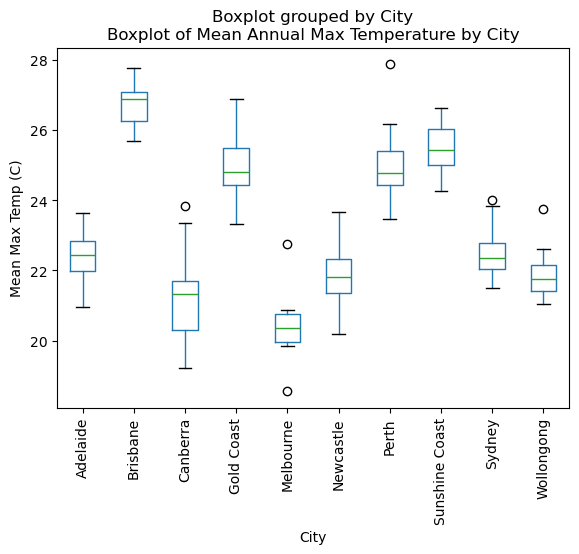

In [35]:
# Checking a boxplot of annual temps by city
plt.figure(figsize=(20, 8))
cities_df.boxplot(column="Mean_Max_Temp", by="City", grid=False)
plt.title("Boxplot of Mean Annual Max Temperature by City")
plt.ylabel("Mean Max Temp (C)")
plt.xticks(rotation=90)  # Rotate city names vertically
plt.savefig(os.path.join(OUTPUTS_DIR, "urban_heat_island", "boxplot_mean_annual_max_temp_bycity.png"))
plt.show()

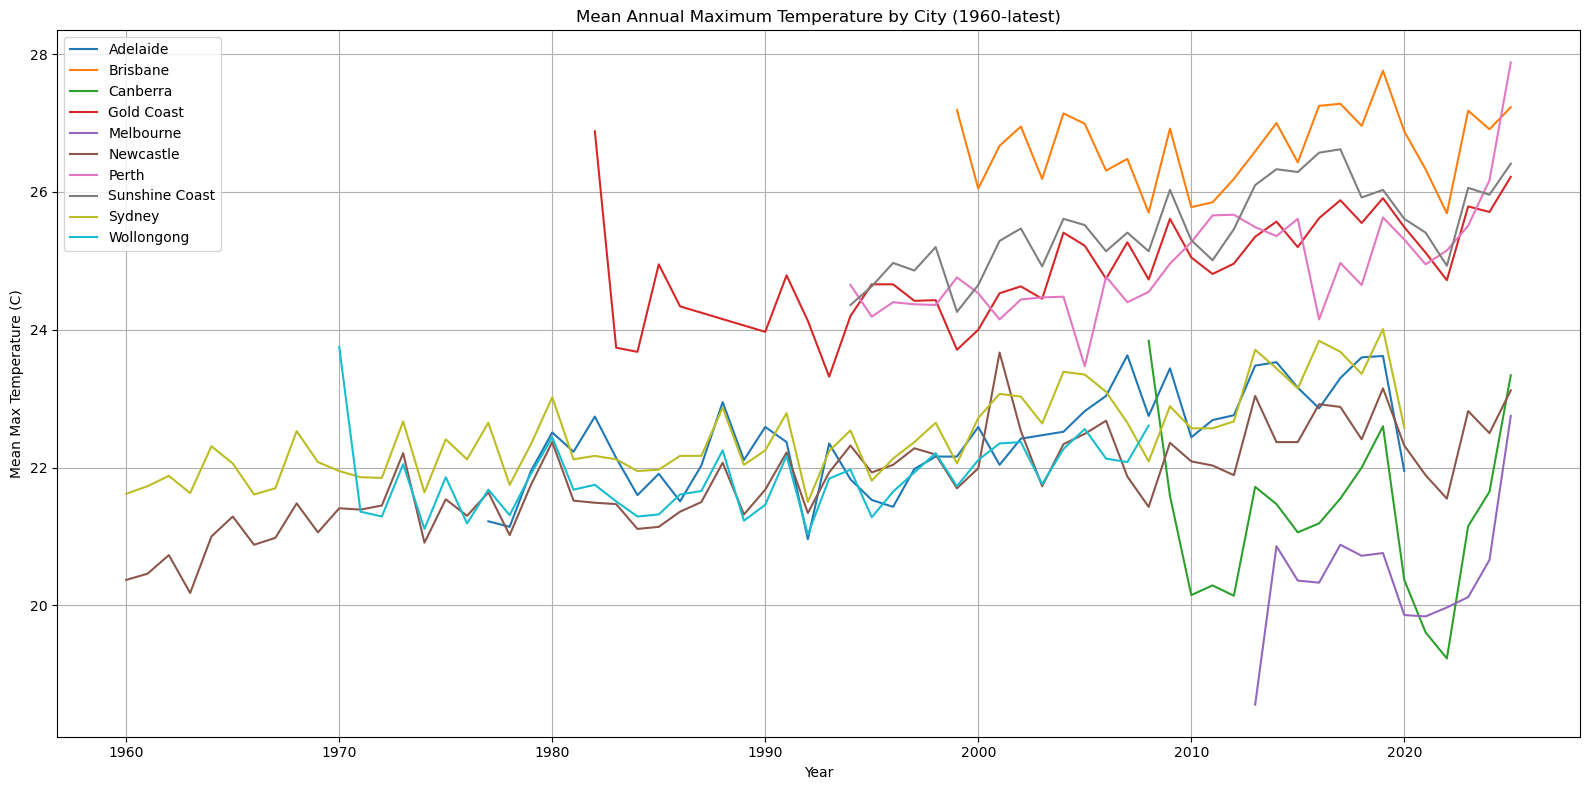

In [36]:
plt.figure(figsize=(16, 8))
for city in sorted(cities_df["City"].unique()):
    subset = cities_df[cities_df["City"] == city]
    plt.plot(subset["Year"], subset["Mean_Max_Temp"], label=city)

plt.title("Mean Annual Maximum Temperature by City (1960-latest)")
plt.xlabel("Year")
plt.ylabel("Mean Max Temperature (C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "urban_heat_island", "mean_max_annual_temp_bycity.png"))
plt.show()

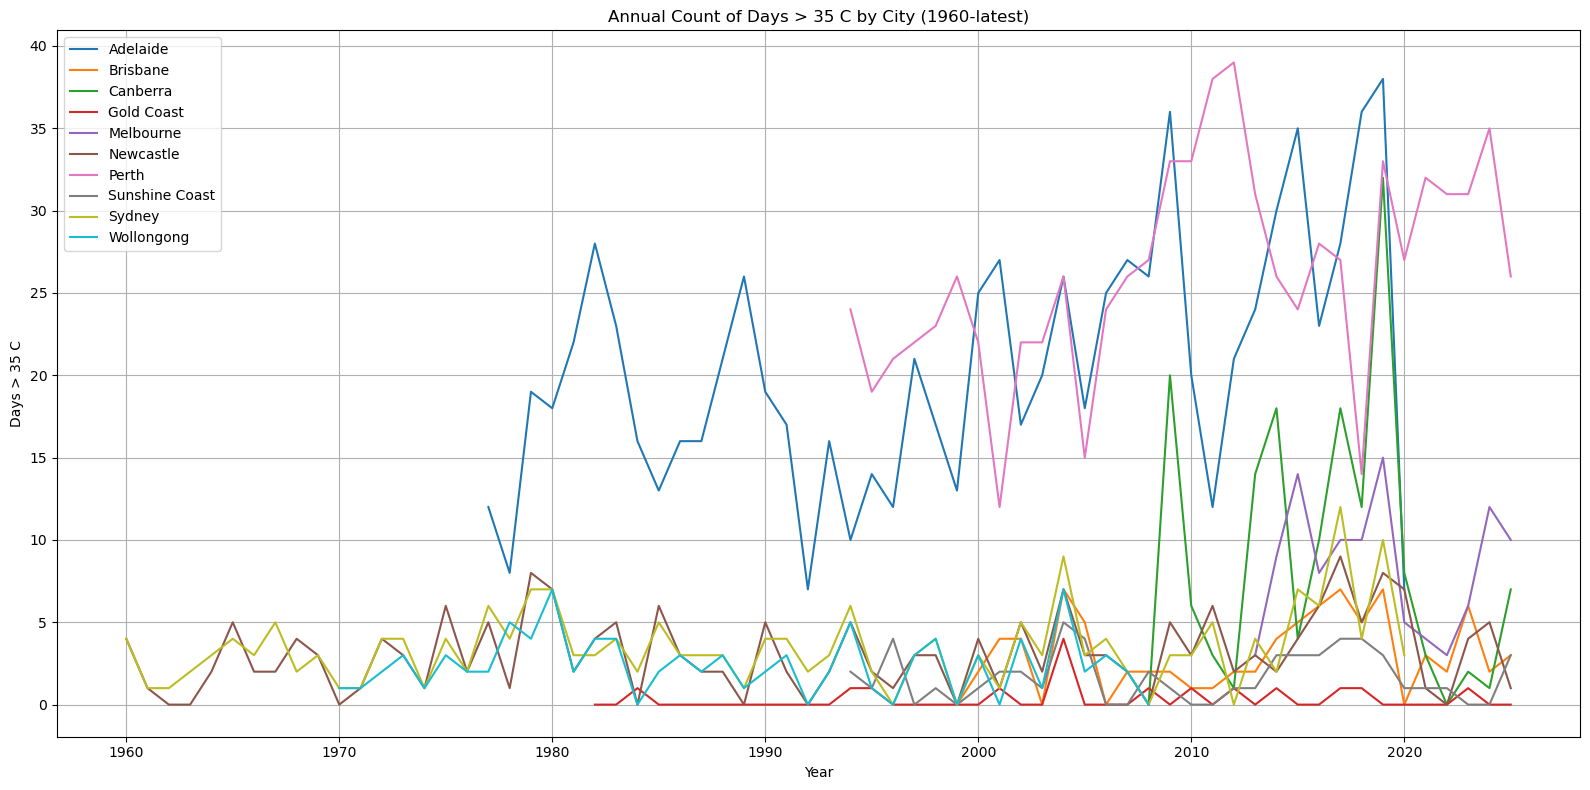

In [37]:
plt.figure(figsize=(16, 8))
for city in sorted(cities_df["City"].unique()):
    subset = cities_df[cities_df["City"] == city]
    plt.plot(subset["Year"], subset["Days_Above_35C"], label=city)

plt.title("Annual Count of Days > 35 C by City (1960-latest)")
plt.xlabel("Year")
plt.ylabel("Days > 35 C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "urban_heat_island", "annual_days_above35_bycity.png"))
plt.show()

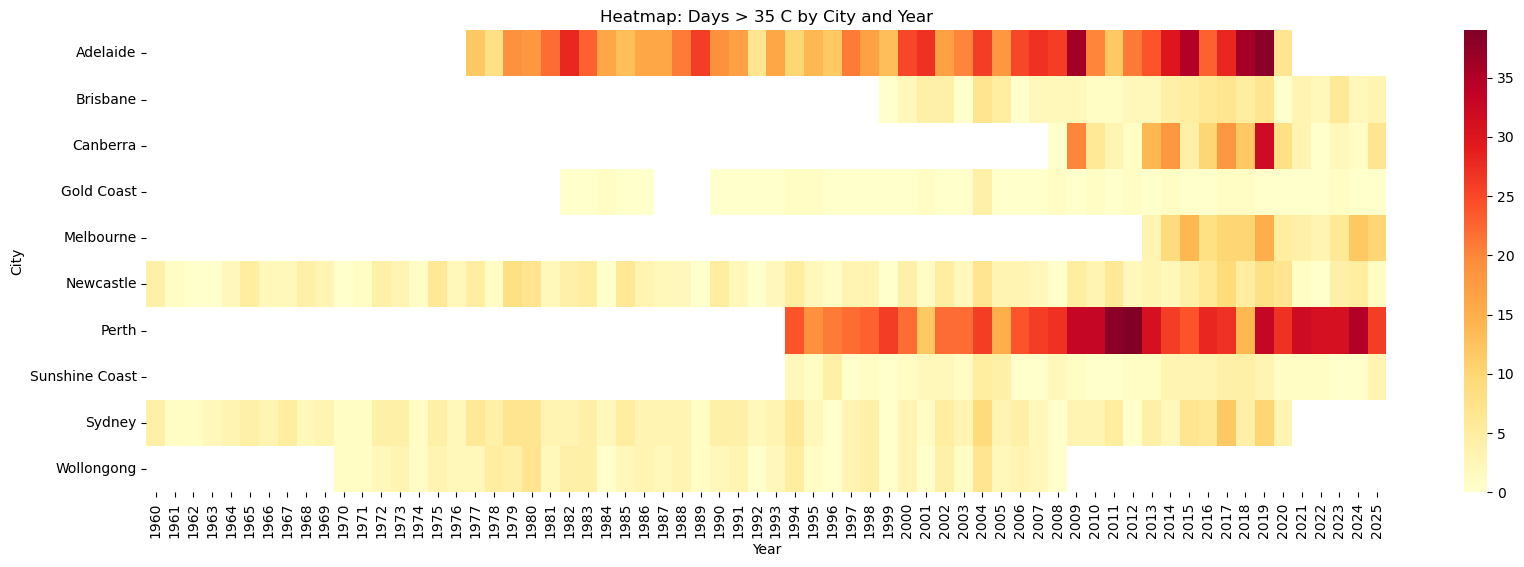

In [38]:
pivot = cities_df.pivot(index="City", columns="Year", values="Days_Above_35C")
plt.figure(figsize=(20, 6))
sns.heatmap(pivot, annot=False, cmap="YlOrRd")
plt.title("Heatmap: Days > 35 C by City and Year")
plt.xlabel("Year")
plt.ylabel("City")
plt.savefig(os.path.join(OUTPUTS_DIR, "urban_heat_island", "heatmap_days_above35_bycity.png"))
plt.show()

